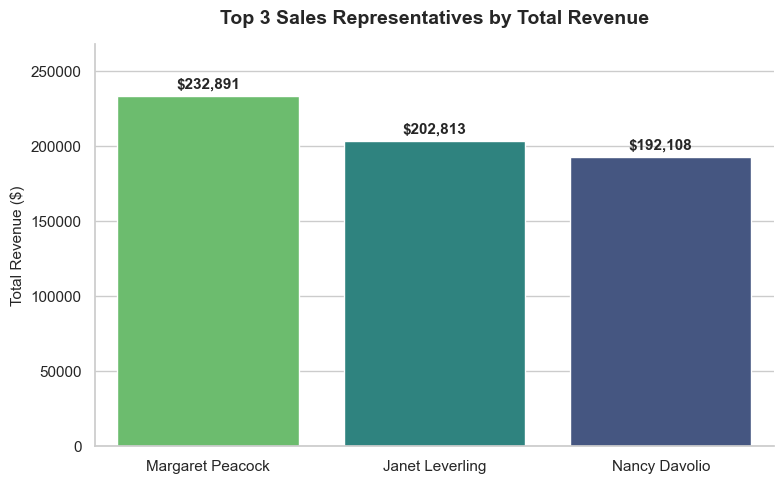

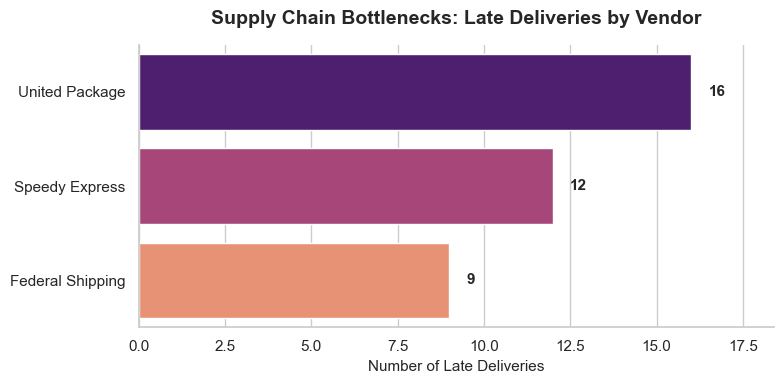

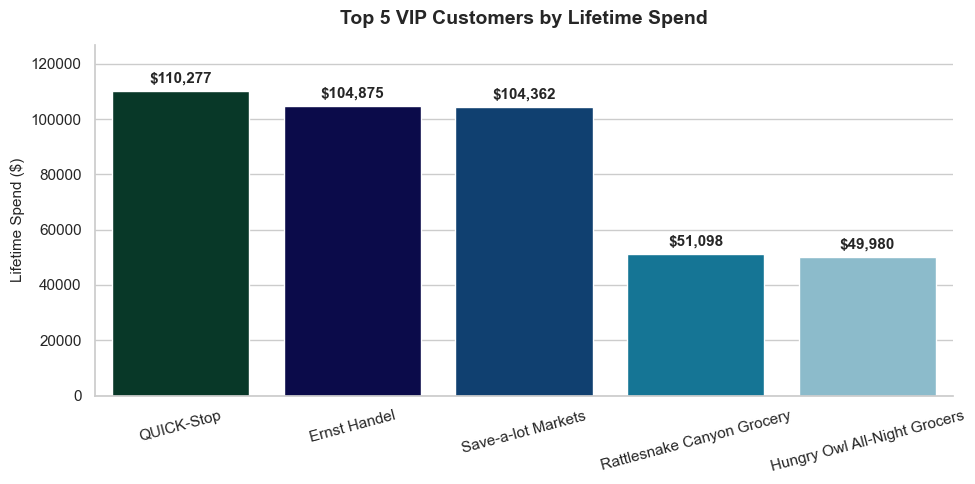

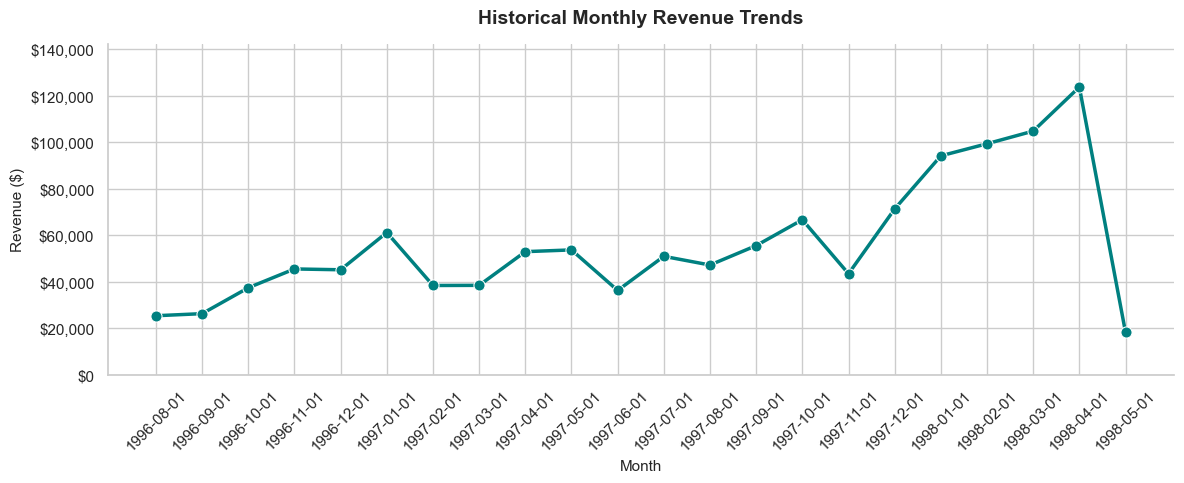

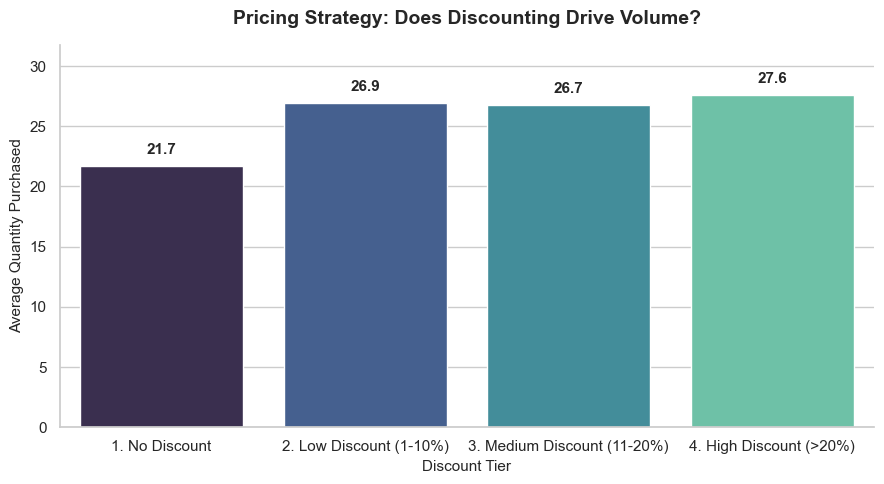

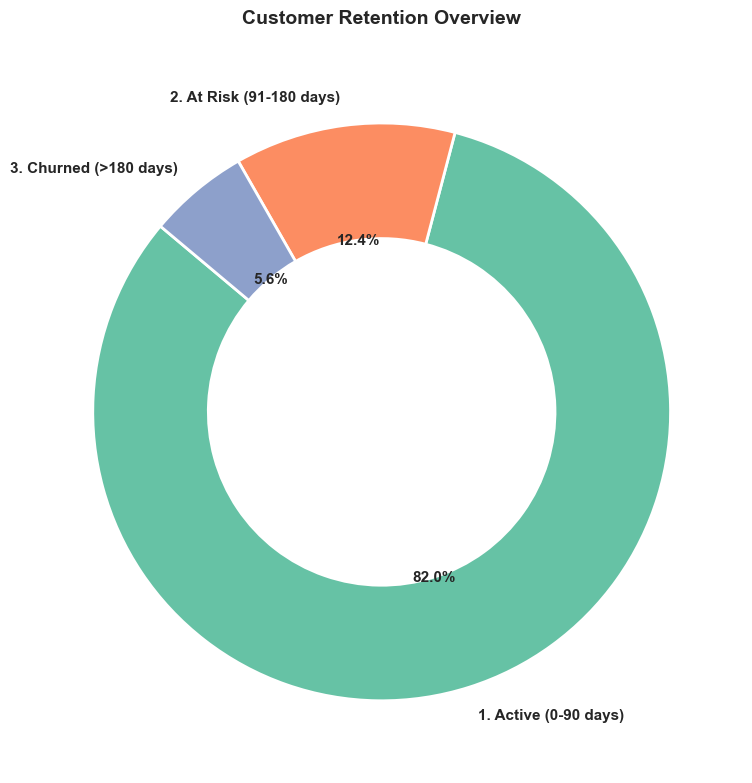

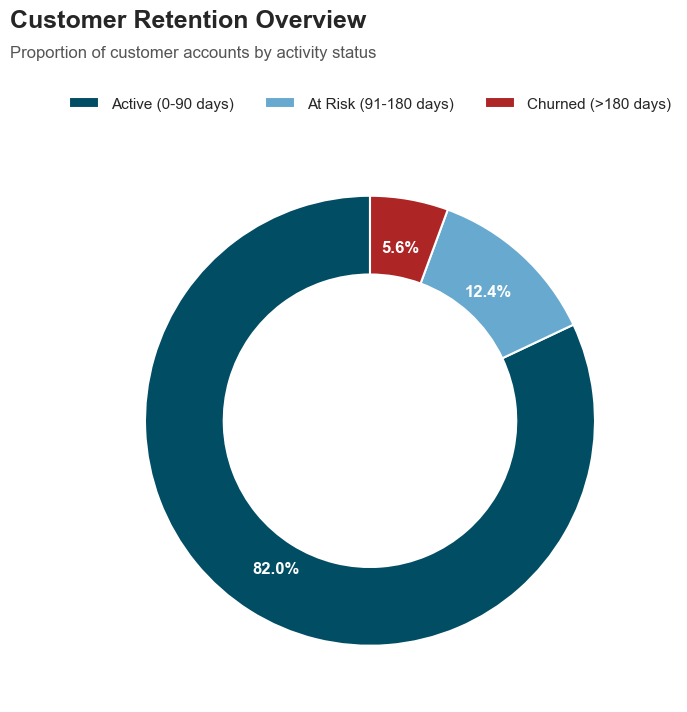

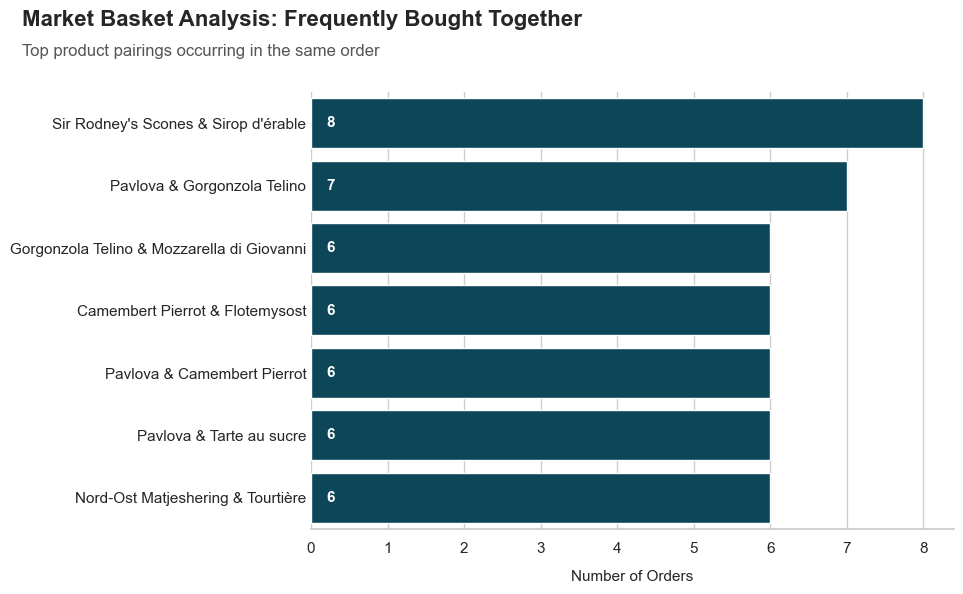

In [15]:
# Import required libraries for data manipulation and visualisation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure the global visual theme for all subsequent charts
sns.set_theme(style="whitegrid")

# === 1. TOP PERFORMING EMPLOYEES ===
df_emp = pd.read_csv('Dataset/top_employees.csv')

plt.figure(figsize=(8, 5))

# Extract the viridis palette for 3 items and swap the 1st and 3rd colors
base_palette = sns.color_palette("viridis", 3)
custom_palette = [base_palette[2], base_palette[1], base_palette[0]]

ax1 = sns.barplot(
    x='employee_name', 
    y='total_revenue', 
    data=df_emp, 
    hue='employee_name',
    palette=custom_palette,
    legend=False
)

plt.title('Top 3 Sales Representatives by Total Revenue', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Total Revenue ($)', fontsize=11)
plt.xlabel('')

# Expand the y-axis limit by 15% to give the labels plenty of room to float
ax1.set_ylim(0, df_emp['total_revenue'].max() * 1.15)

# Annotate bars with full comma-separated numbers, adding a 6000-point offset for separation
for i, v in enumerate(df_emp['total_revenue']):
    ax1.text(i, v + 6000, f"${v:,.0f}", ha='center', fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.savefig('Chart_1_Top_Employees.png', dpi=300)
plt.show()

# === 2. SUPPLY CHAIN: LATE SHIPMENTS ===
df_ship = pd.read_csv('Dataset/late_shipments.csv')

plt.figure(figsize=(8, 4))
ax2 = sns.barplot(
    x='late_deliveries', 
    y='shipper_name', 
    data=df_ship, 
    hue='shipper_name',
    palette="magma",
    legend=False
)

plt.title('Supply Chain Bottlenecks: Late Deliveries by Vendor', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Late Deliveries', fontsize=11)
plt.ylabel('') 

# Expand the x-axis limit by 15% to give the labels room to float
ax2.set_xlim(0, df_ship['late_deliveries'].max() * 1.15)

# Annotate bars with the exact count, adding a 0.5 offset for separation
for i, v in enumerate(df_ship['late_deliveries']):
    ax2.text(v + 0.5, i, str(v), va='center', fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.savefig('Chart_2_Late_Shipments.png', dpi=300)
plt.show()

# === 3. CUSTOMER SEGMENTATION: VIP CUSTOMERS ===
df_vip = pd.read_csv('Dataset/vip_customers.csv').head(5)

plt.figure(figsize=(10, 5))
ax3 = sns.barplot(
    x='company_name', 
    y='lifetime_spend', 
    data=df_vip, 
    hue='company_name',
    palette="ocean",
    legend=False
)

plt.title('Top 5 VIP Customers by Lifetime Spend', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Lifetime Spend ($)', fontsize=11)
plt.xlabel('')
plt.xticks(rotation=15)

# Expand the y-axis limit by 15% to give the labels room to float
ax3.set_ylim(0, df_vip['lifetime_spend'].max() * 1.15)

# Annotate bars with full comma-separated numbers, adding an offset for separation
for i, v in enumerate(df_vip['lifetime_spend']):
    ax3.text(i, v + 3000, f"${v:,.0f}", ha='center', fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.savefig('Chart_3_VIP_Customers.png', dpi=300)
plt.show()

# === 4. MONTH-OVER-MONTH REVENUE GROWTH ===
df_mom = pd.read_csv('Dataset/mom_growth.csv').dropna(subset=['mom_growth_percentage']) 

plt.figure(figsize=(12, 5))

# Generate the line plot
ax4 = sns.lineplot(
    x='order_month', 
    y='current_month_revenue', 
    data=df_mom, 
    marker='o', 
    color='teal', 
    linewidth=2.5, 
    markersize=8
)

plt.title('Historical Monthly Revenue Trends', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Revenue ($)', fontsize=11)
plt.xlabel('Month', fontsize=11)
plt.xticks(rotation=45)

# Format the y-axis to show full comma-separated dollar amounts (e.g., 50,000 instead of 50000)
import matplotlib.ticker as ticker
ax4.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x:,.0f}'))

# Expand the y-axis limit slightly so the peak doesn't touch the top border
ax4.set_ylim(0, df_mom['current_month_revenue'].max() * 1.15)

sns.despine()
plt.tight_layout()
plt.savefig('Chart_4_MoM_Revenue.png', dpi=300)
plt.show()

# === 5. PRICING STRATEGY: DISCOUNT EFFECTIVENESS ===
df_disc = pd.read_csv('Dataset/discount_effectiveness.csv')

plt.figure(figsize=(9, 5))
ax5 = sns.barplot(
    x='discount_tier', 
    y='avg_quantity_purchased', 
    data=df_disc, 
    hue='discount_tier',
    palette="mako",
    legend=False
)

plt.title('Pricing Strategy: Does Discounting Drive Volume?', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Average Quantity Purchased', fontsize=11)
plt.xlabel('Discount Tier', fontsize=11)

# Expand the y-axis limit by 15% to give the labels room to float
ax5.set_ylim(0, df_disc['avg_quantity_purchased'].max() * 1.15)

# Annotate bars with the exact average, adding an offset for separation
for i, v in enumerate(df_disc['avg_quantity_purchased']):
    ax5.text(i, v + 1, str(round(v, 1)), ha='center', fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.savefig('Chart_5_Discount_Effectiveness.png', dpi=300)
plt.show()

# === 6. CUSTOMER RETENTION & CHURN ===
df_churn = pd.read_csv('Dataset/customer_churn.csv')
churn_counts = df_churn['customer_status'].value_counts()

plt.figure(figsize=(8, 8))

# Generate a donut chart
plt.pie(
    churn_counts, 
    labels=churn_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette("Set2"), 
    wedgeprops=dict(width=0.4, edgecolor='w', linewidth=2),
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

plt.title('Customer Retention Overview', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('Chart_6_Customer_Churn.png', dpi=300)
plt.show()

# === 6. CUSTOMER RETENTION & CHURN (The Economist Style) ===
df_churn = pd.read_csv('Dataset/customer_churn.csv')

# Clean the labels
df_churn['clean_status'] = df_churn['customer_status'].apply(lambda x: x.split('. ')[-1] if '. ' in x else x)
churn_counts = df_churn['clean_status'].value_counts()

# The Economist-inspired color palette
color_map = {
    'Active (0-90 days)': '#014d64',     # Deep Editorial Blue
    'At Risk (91-180 days)': '#67a9cf',  # Steel Blue
    'Churned (>180 days)': '#ad2524'     # Crimson Red
}
colors = [color_map.get(label, '#808080') for label in churn_counts.index]

# Create figure with specific dimensions
fig, ax = plt.subplots(figsize=(8, 7.5))

# Lock the exact position of the chart to prevent squishing [left, bottom, width, height]
ax.set_position([0.1, 0.05, 0.8, 0.75])

# Draw the donut chart
wedges, texts, autotexts = ax.pie(
    churn_counts, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors,
    pctdistance=0.78, 
    wedgeprops=dict(width=0.35, edgecolor='white', linewidth=1.5)
)

# Format the internal percentages
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

# Left-aligned editorial titles locked to figure coordinates
plt.figtext(0.05, 0.95, 'Customer Retention Overview', fontsize=18, fontweight='bold', fontfamily='sans-serif')
plt.figtext(0.05, 0.91, 'Proportion of customer accounts by activity status', fontsize=12, color='#555555')

# Horizontal legend perfectly centered under the titles, above the chart
ax.legend(
    wedges, 
    churn_counts.index,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.10),
    ncol=3, # Spreads the legend horizontally
    frameon=False,
    fontsize=11
)

# Save without tight_layout to preserve our exact custom coordinates
plt.savefig('Chart_6_Customer_Churn.png', dpi=300, bbox_inches='tight')
plt.show()

# === 7. MARKET BASKET ANALYSIS (Editorial Style) ===
df_basket = pd.read_csv('Dataset/market_basket.csv').head(7)

# Format the pairing text cleanly
df_basket['pair'] = df_basket['product_a'] + " & " + df_basket['product_b']

fig, ax = plt.subplots(figsize=(10, 6))

# Generate the bar plot using a single, sharp editorial color
sns.barplot(
    x='times_bought_together', 
    y='pair', 
    data=df_basket, 
    color="#014d64", # Deep Editorial Blue
    ax=ax
)

# Editorial Titles
plt.figtext(0.05, 0.96, 'Market Basket Analysis: Frequently Bought Together', fontsize=16, fontweight='bold')
plt.figtext(0.05, 0.91, 'Top product pairings occurring in the same order', fontsize=12, color='#555555')

# Axis formatting
plt.xlabel('Number of Orders', fontsize=11, labelpad=10)
plt.ylabel('') # Remove y-label (it's self explanatory)
ax.set_title('') # Remove default title

# Remove all borders except the bottom axis for a clean, floating look
sns.despine(left=True, bottom=False)

# Remove the y-axis tick marks
ax.tick_params(axis='y', length=0)

# Inject the numbers inside the base of the bars for a sleek, modern look
for i, v in enumerate(df_basket['times_bought_together']):
    ax.text(0.2, i, str(v), color='white', va='center', fontsize=11, fontweight='bold')

plt.tight_layout(rect=[0.02, 0, 1, 0.88]) # Ensure titles aren't cut off
plt.savefig('Chart_7_Market_Basket.png', dpi=300)
plt.show()
